# Load Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier

# Load Dataset

In [3]:
df = pd.read_csv('./data_C.csv')
df.head()

,Unnamed: 0,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,churn
0,0,157138,15638646,Chinweike,628.0,Spain,Female,50.0,4,160133.08,1,1,1,653.53,0
1,1,116144,15695825,Onwumelu,710.0,Spain,Male,34.0,8,0.00,2,1,1,72993.73,0
2,2,145603,15592765,Marks,663.0,France,Female,23.0,8,125470.81,1,1,1,174536.17,0
3,3,79929,15807525,Onyemachukwu,644.0,Spain,Male,45.0,8,0.00,2,0,1,28690.90,0
4,4,52554,15611551,Hill,627.0,Spain,Male,23.0,5,0.00,2,1,0,134483.07,0


# Data Exploration

## Data Basic Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41258 entries, 0 to 41257
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       41258 non-null  int64  
 1   id               41258 non-null  int64  
 2   CustomerId       41258 non-null  int64  
 3   Surname          41258 non-null  object 
 4   CreditScore      41246 non-null  float64
 5   Geography        41258 non-null  object 
 6   Gender           41258 non-null  object 
 7   Age              41258 non-null  float64
 8   Tenure           41258 non-null  int64  
 9   Balance          41258 non-null  float64
 10  NumOfProducts    41258 non-null  int64  
 11  HasCrCard        41258 non-null  int64  
 12  IsActiveMember   41258 non-null  int64  
 13  EstimatedSalary  41258 non-null  float64
 14  churn            41258 non-null  int64  
dtypes: float64(4), int64(8), object(3)
memory usage: 4.7+ MB


The dataset has 41258 rows and 14 columns. With 13 features and 1 target variable. 
We will separate the dataset into 3 section : 
- Customer Identification : Surname, Geography, Gender, Age
- Customer Attributes : Credit Score, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary
- Target Variables : churn

With unrecognizable variables like Unnamed: 0 and unique identification number like id and CustomerId as irrelevant variables.

## Customer Identification

### Surname

In [5]:
df['Surname'].value_counts().head(10)

Surname
Hsia       636
T'ien      571
Maclean    430
Kao        405
Hs?        397
Ts'ui      382
P'eng      361
H?         361
Ch'ang     334
Shih       314
Name: count, dtype: int64

In [6]:
df['Surname'].value_counts().tail(10)

Surname
Olson             1
Verco             1
Threatt           1
Nikitina          1
Vasiliev          1
Hopetoun          1
Wollstonecraft    1
Walkom            1
Fitzgerald        1
Igwebuike         1
Name: count, dtype: int64

In [7]:
df['Surname'].unique().shape

(2272,)

In [8]:
df['Surname'].isnull().sum()

0

The Surname Variable is a string variable with 2272 unique values with 0 missing values. 
The top 10 most prevalent surnames are as follows:
- Hsia       636
- T'ien      571
- Maclean    430
- Kao        405
- Hs?        397
- Ts'ui      382
- P'eng      361
- H?         361
- Ch'ang     334
- Shih       314

The top 10 least prevalent surnames are as follows:
- Olson             1
- Verco             1
- Threatt           1
- Nikitina          1
- Vasiliev          1
- Hopetoun          1
- Wollstonecraft    1
- Walkom            1
- Fitzgerald        1
- Igwebuike         1

### Geography

<Axes: xlabel='Geography'>

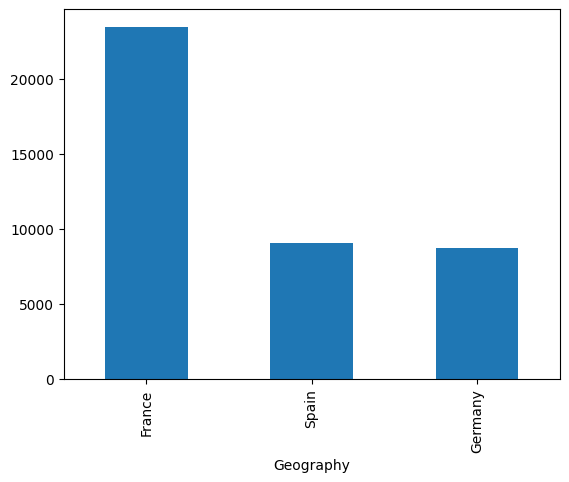

In [9]:
df['Geography'].value_counts().plot(kind='bar')

In [10]:
df['Geography'].value_counts(normalize=True)

Geography
France     0.568835
Spain      0.219521
Germany    0.211644
Name: proportion, dtype: float64

In [11]:
df['Geography'].isnull().sum()

0

The Geography Variable is a Categorical Variable with 3 unique values with 0 missing values. The distribution of this variable is mostly centered on France, with it having 57% of the data, with Germany and Spain having 22% and 11% respectively.

### Gender

<Axes: xlabel='Gender'>

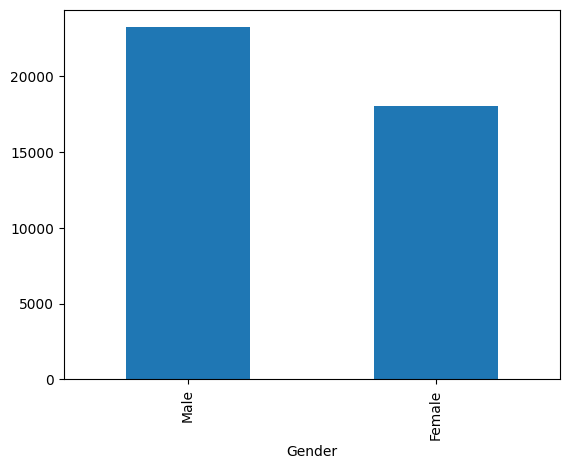

In [12]:
df['Gender'].value_counts().plot(kind='bar')

In [13]:
df['Gender'].value_counts(normalize=True)

Gender
Male      0.562776
Female    0.437224
Name: proportion, dtype: float64

In [14]:
df['Gender'].isnull().sum()

0

The Gender Variable is a Categorical Variable with 2 unique values with 0 missing values. The distribution of this variable is almost even between male and female, with Male having 56% and Female having 44%.

### Age

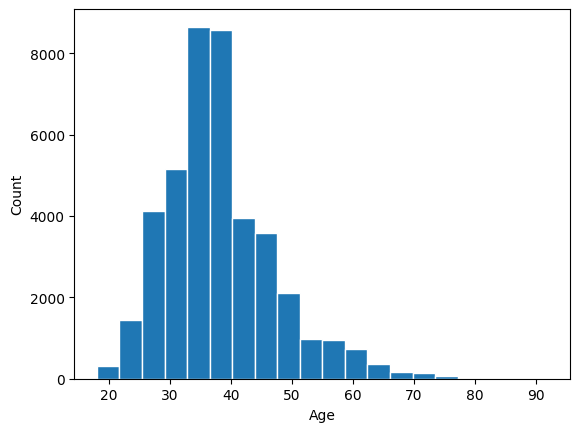

In [15]:
plt.hist(df['Age'], edgecolor='white', bins=20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [16]:
print(df['Age'].describe())
print(df['Age'].isnull().sum())
print(df['Age'].unique().shape)

count    41258.000000
mean        38.165611
std          8.947665
min         18.000000
25%         32.000000
50%         37.000000
75%         42.750000
max         92.000000
Name: Age, dtype: float64
0
(71,)


The distribution of the Age variable is shaped like a bell curved which is slightly right skewed but mostly centered around the mean of 38.17 or 30 - 40 years old. with 0 missing values The minimum age is 18 and the maximum age is 92. With standard deviation of 8.95. The missing values for this variable is 0. 

The distribution of the age indicates that age is normally distributed with a few customer being an elderly seen by the trail on the right.

## Customer Attributes

### Credit Score

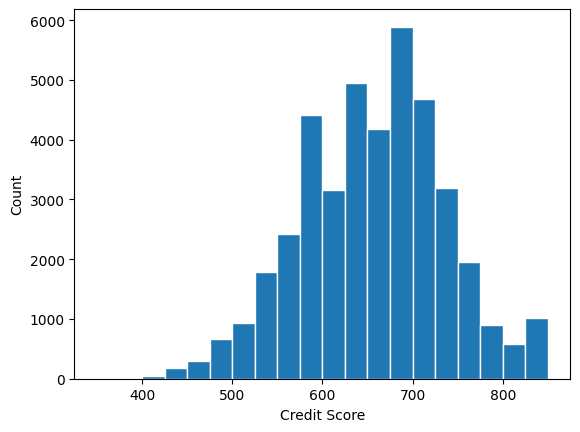

In [17]:
plt.hist(df['CreditScore'], edgecolor='white', bins=20)
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()

In [18]:
print(df['CreditScore'].describe())
print(df['CreditScore'].isnull().sum())
print(df['CreditScore'].unique().shape)

count    41246.000000
mean       655.802890
std         79.736298
min        350.000000
25%        597.000000
50%        659.000000
75%        710.000000
max        850.000000
Name: CreditScore, dtype: float64
12
(445,)


The Credit Score Variable is a numerical variable with 445 unique values with 12 missing values. The distribution of this variable is normally distributed with a mean of 655.80 or 600 - 700 and a standard deviation of 79.74. The minimum credit score is 350 and the maximum credit score is 850.

### Tenure

<Axes: xlabel='Tenure'>

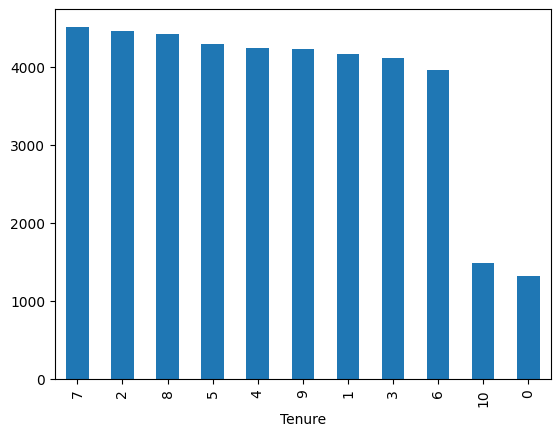

In [19]:
df['Tenure'].value_counts().plot(kind='bar')

In [20]:
df['Tenure'].value_counts(normalize=True)

Tenure
7     0.109458
2     0.108318
8     0.107228
5     0.104149
4     0.103083
9     0.102768
1     0.101241
3     0.099714
6     0.095981
10    0.036138
0     0.031921
Name: proportion, dtype: float64

The Tenure Variable is a Categorical Variable with 11 unique values with 0 missing values. The distribution of this variable is mostly even for all values except for 10 and 0, with the minimum tenure being 0 and the maximum tenure being 10 years. 

This indicates that the tenure is mostly evenly distributed with a few customers having 0 or 10 years of tenure.

### Balance

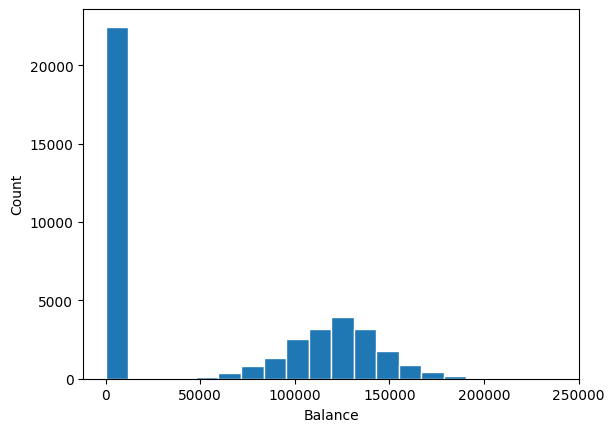

In [21]:
plt.hist(df['Balance'], edgecolor='white', bins=20)
plt.xlabel('Balance')
plt.ylabel('Count')
plt.show()

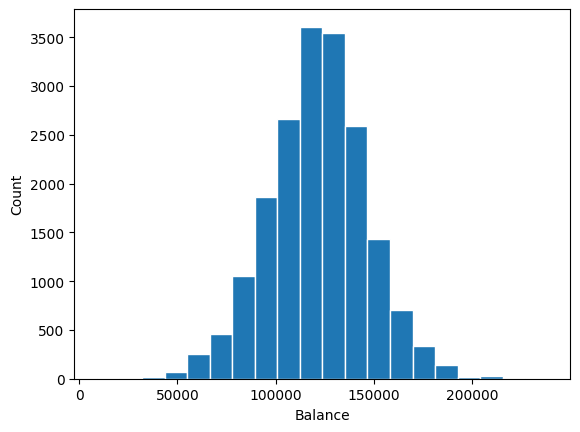

In [22]:
plt.hist(df[df['Balance'] > 0]['Balance'], edgecolor='white', bins=20)
plt.xlabel('Balance')
plt.ylabel('Count')
plt.show()

In [23]:
print(df['Balance'].describe())
print(df['Balance'].isnull().sum())
print(df['Balance'].unique().shape)

count     41258.000000
mean      55308.965471
std       62795.530950
min           0.000000
25%           0.000000
50%           0.000000
75%      119785.395000
max      238387.560000
Name: Balance, dtype: float64
0
(11410,)


In [24]:
print(df[df['Balance'] > 0]['Balance'].describe())
print(df[df['Balance'] > 0]['Balance'].isnull().sum())
print(df[df['Balance'] > 0]['Balance'].unique().shape)

count     18787.00000
mean     121463.63429
std       24984.87081
min        9053.36000
25%      105335.60500
50%      122314.50000
75%      137841.51500
max      238387.56000
Name: Balance, dtype: float64
0
(11409,)


The Balance Variable is centered mostly around 0 with a few customers having a balance of 0. With 0 missing values. The minimum balance is 0 and the maximum balance is 238387.56. With a mean of 55308.966 and a standard deviation of 62795.53. But for customer with balance greater than 0, the distribution normally distributed with mean of 121463.63 and standart deviation of 24984.9.

This indicates that most customers have a balance of 0, with a few customers having a balance greater than 0 thats normally distributed.

### Number of Products

<Axes: xlabel='NumOfProducts'>

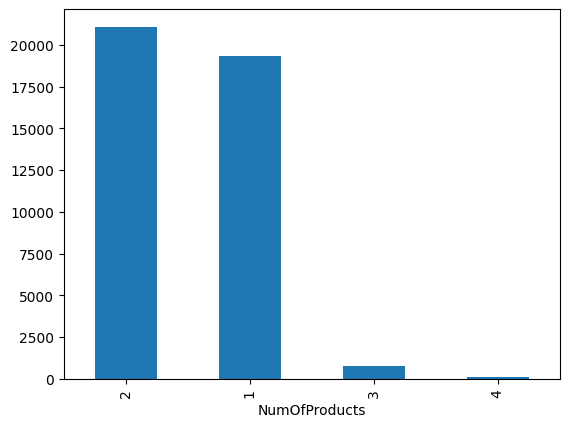

In [25]:
df['NumOfProducts'].value_counts().plot(kind='bar')

In [26]:
df['NumOfProducts'].value_counts(normalize=True)

NumOfProducts
2    0.510931
1    0.467909
3    0.018372
4    0.002787
Name: proportion, dtype: float64

In [27]:
df['NumOfProducts'].isnull().sum()

0

The Number of Products Variable is a Categorical Variable with 4 unique values with 0 missing values. The distribution of this variable is mostly centered on 1 and 2, with 1 having 46% of the data and 2 having 51% of the data, with 3 and 4 having 1% and 0.2%.

### Has Credit Card

<Axes: xlabel='HasCrCard'>

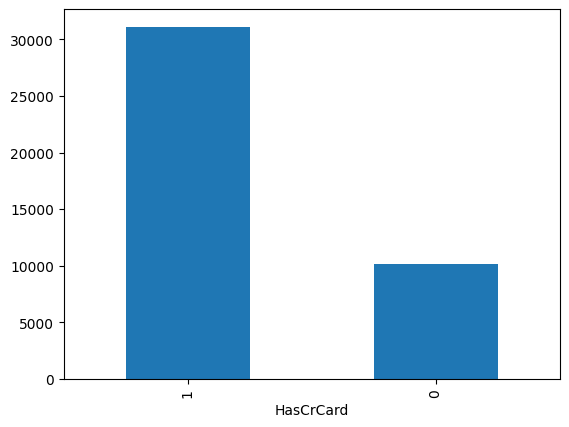

In [28]:
df['HasCrCard'].value_counts().plot(kind='bar')

In [29]:
df['HasCrCard'].value_counts(normalize=True)

HasCrCard
1    0.754011
0    0.245989
Name: proportion, dtype: float64

In [30]:
df['HasCrCard'].isnull().sum()

0

The Has Credit Card Variable is a Categorical Variable with 2 unique values with 0 missing values. The distribution of this variable is almost even between 0 and 1, with 75% of the data having a credit card and 25% of the data not having a credit card.

### Is Active Member

<Axes: xlabel='IsActiveMember'>

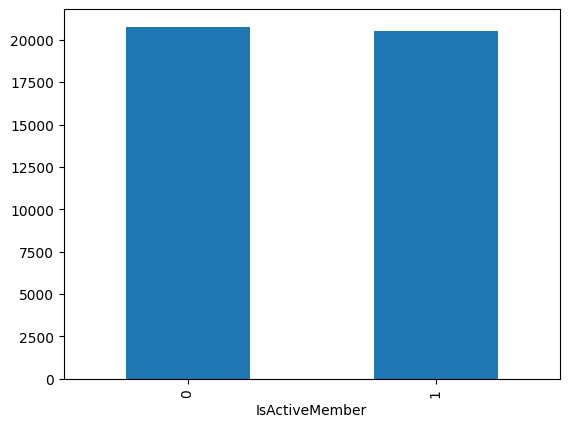

In [31]:
df['IsActiveMember'].value_counts().plot(kind='bar')

In [32]:
df['IsActiveMember'].value_counts(normalize=True)

IsActiveMember
0    0.503224
1    0.496776
Name: proportion, dtype: float64

In [33]:
df['IsActiveMember'].isnull().sum()

0

The Is Active Member Variable is a Categorical Variable with 2 unique values with 0 missing values. The distribution of this variable is almost even between 0 and 1, with each having almost 50% of the data

### Estimated Salary

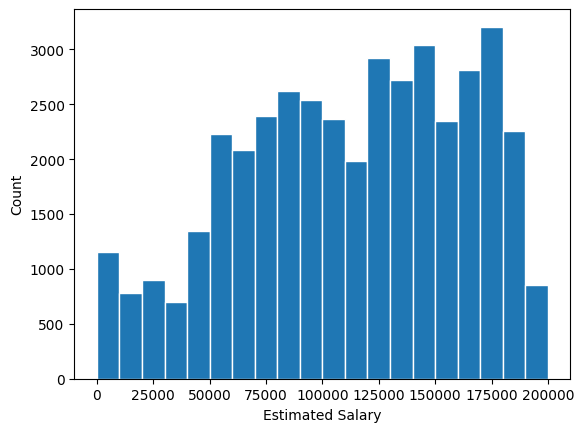

In [34]:
plt.hist(df['EstimatedSalary'], edgecolor='white', bins=20)
plt.xlabel('Estimated Salary')
plt.ylabel('Count')
plt.show()

In [35]:
print(df['EstimatedSalary'].describe())
print(df['EstimatedSalary'].isnull().sum())
print(df['EstimatedSalary'].unique().shape)

count     41258.000000
mean     112507.486040
std       50048.666663
min          11.580000
25%       74564.410000
50%      117616.290000
75%      154700.647500
max      199992.480000
Name: EstimatedSalary, dtype: float64
0
(20841,)


The Estimated Salary Variable is a Numerical Variable with 20841 Unique values with 0 missing values. The distribution of this variable is similar to multimodal distribution with mean of 112507.49 and standard deviation of 50048.67. The minimum salary is 11.58 and the maximum salary is 199992.48.

## Target Variable

### Description

<Axes: xlabel='churn'>

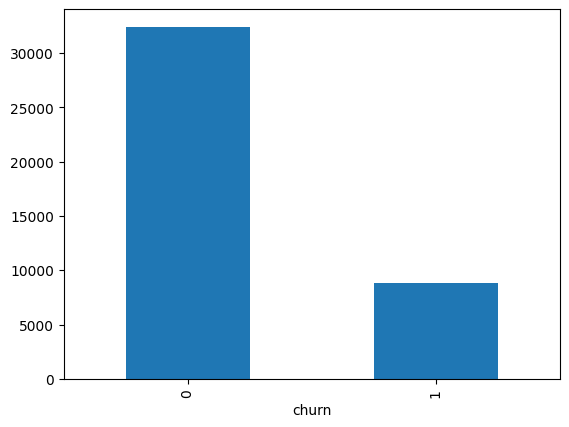

In [36]:
df['churn'].value_counts().plot(kind='bar')

In [37]:
df['churn'].value_counts(normalize=True)

churn
0    0.785545
1    0.214455
Name: proportion, dtype: float64

In [38]:
df['churn'].isnull().sum()

0

The Churn Variable is a Categorical Variable with 2 unique values with 0 missing values. The distribution of this variable is centered on 0 with it having 79% of the data and 1 having 21% of the data. This indicates that most customer is not churned/stopped using the services.

# Data Preparation

What to do:
- Drop irrelevant variables
- Changing String Variable to Categorical
- Impute missing value with median for numerical and mode for categorical
- Split dataset
- do encoding on the categorical data
- do scaling on the numerical data
- Feature Selection Based on Train Data using Decission Tree

## Dropping Irrlevant Variables

In [39]:
newDF = df.drop(columns=['Unnamed: 0', 'id', 'CustomerId'], axis=1)

## Change String variable to categorical

### Surname

Description
- More than 100 -> Very Prevalen
- Less than 100 & More than 50 -> Prevalen
- Less than 50 & More than 25 -> A bit Prevalen
- Less than 25 & More than 10 -> Not Prevalen 
- Less than 10 -> Very Not Prevalen

In [40]:
categoricSurnameDict = {'Very Prevalen': [], 'Prevalent': [], 'A bit Prevalen': [], 'Not Prevalen': [], 'Very Not Prevalen': []}

for surname, count in df['Surname'].value_counts().items():
    if count >= 100:
        categoricSurnameDict['Very Prevalen'].append(surname)
    elif count >= 50:
        categoricSurnameDict['Prevalent'].append(surname)
    elif count >= 25:
        categoricSurnameDict['A bit Prevalen'].append(surname)
    elif count >= 10:
        categoricSurnameDict['Not Prevalen'].append(surname)
    else:
        categoricSurnameDict['Very Not Prevalen'].append(surname)

In [41]:
newDF['Surname Prevalency'] = newDF['Surname'].apply(lambda x: 'Very Prevalen' if x in categoricSurnameDict['Very Prevalen'] else 'Prevalent' if x in categoricSurnameDict['Prevalent'] else 'A bit Prevalen' if x in categoricSurnameDict['A bit Prevalen'] else 'Not Prevalen' if x in categoricSurnameDict['Not Prevalen'] else 'Very Not Prevalen')

In [42]:
finalDF = newDF.drop(columns=['Surname'], axis=1)

In [43]:
finalDF.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,churn,Surname Prevalency
0,628.0,Spain,Female,50.0,4,160133.08,1,1,1,653.53,0,Not Prevalen
1,710.0,Spain,Male,34.0,8,0.00,2,1,1,72993.73,0,Very Prevalen
2,663.0,France,Female,23.0,8,125470.81,1,1,1,174536.17,0,Very Not Prevalen
3,644.0,Spain,Male,45.0,8,0.00,2,0,1,28690.90,0,Prevalent
4,627.0,Spain,Male,23.0,5,0.00,2,1,0,134483.07,0,Not Prevalen


## Inputing Missing Value

In [44]:
finalDF['CreditScore'].fillna(finalDF['CreditScore'].median(), inplace=True)

## Split Dataset

In [45]:
X, y = finalDF.drop(columns=['churn'], axis=1), finalDF['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Encoding

### Train Data

In [46]:
encoder = OneHotEncoder(handle_unknown='infrequent_if_exist')
encoded_x_train = X_train[['Geography', 'Gender', 'Surname Prevalency']]

In [47]:
encoded_train = pd.DataFrame(encoder.fit_transform(encoded_x_train).toarray(), columns=encoder.get_feature_names_out())
# Join the encoded data with the rest of the training data
X_train = X_train.drop(columns=['Geography', 'Gender', 'Surname Prevalency'], axis=1).reset_index()
X_train_enc = pd.concat([X_train, encoded_train], axis=1).drop(columns=['index'], axis=1)
y_train.reset_index(inplace=True, drop=True)

### Test Data

In [48]:
encoded_x_test = X_test[['Geography', 'Gender', 'Surname Prevalency']]
encoded_test = pd.DataFrame(encoder.transform(encoded_x_test).toarray(), columns=encoder.get_feature_names_out())
X_test = X_test.drop(columns=['Geography', 'Gender', 'Surname Prevalency'], axis=1).reset_index()
X_test_enc = pd.concat([X_test, encoded_test], axis=1).drop(columns=['index'], axis=1)
y_test.reset_index(inplace=True, drop=True)

## Scaling (Standard Scaler)

### Train Data

In [49]:
scaler = StandardScaler()
numeric_col = ['CreditScore', 'Balance', 'EstimatedSalary', 'Age']

X_train_enc[numeric_col] = scaler.fit_transform(X_train_enc[numeric_col])

### Test Data

In [50]:
X_test_enc[numeric_col] = scaler.transform(X_test_enc[numeric_col])

In [51]:
X_test_enc.head(
    
)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Surname Prevalency_A bit Prevalen,Surname Prevalency_Not Prevalen,Surname Prevalency_Prevalent,Surname Prevalency_Very Not Prevalen,Surname Prevalency_Very Prevalen
0,1.643974,-0.241409,6,1.828006,1,0,1,-0.225773,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.992913,-0.910526,2,-0.888279,2,1,1,0.404146,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.692423,2.212017,4,-0.888279,1,1,1,0.128539,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.442015,-0.575968,5,-0.888279,2,1,0,-2.210441,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-1.022872,-0.129890,7,1.147837,1,1,0,-1.004706,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Model Building

## Random Forest

### Modelling

In [35]:
randomForest = RandomForestClassifier(random_state=42)

In [36]:
randomForest.fit(X_train_enc, y_train)

RandomForestClassifier(random_state=42)

### Evaluation

#### Train Data

In [37]:
y_train_pred = randomForest.predict(X_train_enc)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22729
           1       1.00      1.00      1.00      6151

    accuracy                           1.00     28880
   macro avg       1.00      1.00      1.00     28880
weighted avg       1.00      1.00      1.00     28880



#### Test Data

In [38]:
y_test_pred = randomForest.predict(X_test_enc)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      9681
           1       0.74      0.54      0.63      2697

    accuracy                           0.86     12378
   macro avg       0.81      0.74      0.77     12378
weighted avg       0.85      0.86      0.85     12378



From the Result of the Evaluation to the train and test data, we can conclude that the model is overfitting based on the difference between the precision, recall, and f1 score for churn category 1 in the train and test data. We will do Hyper parameter tuning to try to achieve a better result.

### Hyper Parameter Tuning

#### Define Hyper Parameter to Tune

In [22]:

param_grid = {
    'n_estimators': [100, 500, 1000],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#### Search for best Hyper Parameter

In [32]:
randomForest = RandomForestClassifier(random_state=42)
randomForestTuning = GridSearchCV(randomForest, param_grid, cv=5, n_jobs=-1, verbose=2, scoring='f1')

In [24]:
randomForestTuning.fit(X_train_enc, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 500, 1000]},
             scoring='f1', verbose=2)

In [25]:
randomForestTuning.best_params_

{'criterion': 'gini',
 'max_depth': 30,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 100}

In [26]:
gridF1 = randomForestTuning.best_score_
gridF1

0.6140409468612317

### Use Best Hyper Parameter

In [39]:
randomForestTuned = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=30, min_samples_split=2, min_samples_leaf=10, criterion='gini')
randomForestTuned.fit(X_train_enc, y_train)

RandomForestClassifier(max_depth=30, min_samples_leaf=10, random_state=42)

#### Evaluation

In [40]:
y_test_pred = randomForestTuned.predict(X_test_enc)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      9681
           1       0.78      0.52      0.63      2697

    accuracy                           0.86     12378
   macro avg       0.83      0.74      0.77     12378
weighted avg       0.86      0.86      0.85     12378



## XGBoost

In [15]:
y_train_obj = y_train.astype(object)

### Base Model

In [16]:
XGboost = XGBClassifier(seed=42, objective='binary:logistic', eval_metric='error', booster='gbtree', random_state=42, verbosity=2, n_jobs=-1, validate_parameters=1, device='gpu')
XGboost.fit(X_train_enc, y_train_obj)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='gpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [17]:
y_train_pred = XGboost.predict(X_train_enc)
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     22729
           1       0.87      0.70      0.78      6151

    accuracy                           0.91     28880
   macro avg       0.90      0.84      0.86     28880
weighted avg       0.91      0.91      0.91     28880



C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:160: UserWarning: [14:34:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [18]:
y_test_pred = XGboost.predict(X_test_enc)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      9681
           1       0.74      0.57      0.64      2697

    accuracy                           0.86     12378
   macro avg       0.81      0.76      0.78     12378
weighted avg       0.85      0.86      0.86     12378



### Hyper Parameter Tuning

In [19]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.1, 0.3, 0.05],
    'colsample_bytree': [0.3, 0.7, 0.8],
    'lambda': [0, 1, 10]
}

In [20]:
XGboost = XGBClassifier(seed=42, objective='binary:logistic', eval_metric='error', booster='gbtree', random_state=42, verbosity=2, n_jobs=-1, validate_parameters=1, device='gpu')
XGboostTuning = GridSearchCV(XGboost, param_grid, cv=5, n_jobs=-1, verbose=2, scoring='f1')
XGboostTuning.fit(X_train_enc, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster='gbtree',
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device='gpu',
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='error', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_ra...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.3, 0.7, 0.8],
                         'lambda': [0, 1, 10],
                         'learning_rate': [0.1, 0.3, 0.05],
                         'max_depth': [3, 4, 5]},
             scoring='f1', verbose=2)

In [21]:
XGboostTuning.best_params_

{'colsample_bytree': 0.8, 'lambda': 0, 'learning_rate': 0.3, 'max_depth': 3}

In [22]:
XGboostF1 = XGboostTuning.best_score_
XGboostF1

0.6282659004020228

In [26]:
XGboost = XGBClassifier(random_state=42, learning_rate=0.3, max_depth=3, colsample_bytree=0.8, _lambda=0,  seed=42, objective='binary:logistic', eval_metric='error', booster='gbtree', verbosity=2, n_jobs=-1, validate_parameters=1, device='gpu')

In [27]:
XGboost.fit(X_train_enc, y_train_obj)

C:\Users\kanek\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:160: UserWarning: [14:40:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "_lambda" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(_lambda=0, base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='gpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [28]:
y_test_pred = XGboost.predict(X_test_enc)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      9681
           1       0.76      0.57      0.66      2697

    accuracy                           0.87     12378
   macro avg       0.83      0.76      0.79     12378
weighted avg       0.86      0.87      0.86     12378



# Conclusion

From the 4 model above we can conclude that the tuned Random Forest Model is better suited for the data and perform better based on it's precision on category 1 in the churn variable of 0.78, this shows that the model can predict the customer that will churn with 78% precision. 

In [41]:
import pickle as pk
pk.dump(randomForestTuned, open('randomForestTuned.pkl', 'wb'))